# Dependencies

Feel free to modify the seed to show different images!  
Just make sure different models are compared on the same set of images.

In [19]:
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import transforms
import torchvision.transforms as standard_transforms
from torch.utils.data import DataLoader
import torch.nn as nn
from torch.utils import data
import os
from PIL import Image

import numpy as np

torch.manual_seed(2025)

In [20]:
train_dataset =torchvision.datasets.VOCSegmentation(root='./data',year='2012',download=True,image_set='train')
val_dataset = torchvision.datasets.VOCSegmentation(root='./data',year='2012',download=True,image_set='val')
test_dataset = torchvision.datasets.VOCSegmentation(root='./data',year='2012',download=True,image_set='val')

100%|██████████| 2.00G/2.00G [01:29<00:00, 22.3MB/s]


In [21]:
num_classes = 21
ignore_label = 255
root = './data'

'''
color map
0=background, 1=aeroplane, 2=bicycle, 3=bird, 4=boat, 5=bottle # 6=bus, 7=car, 8=cat, 9=chair, 10=cow, 11=diningtable,
12=dog, 13=horse, 14=motorbike, 15=person # 16=potted plant, 17=sheep, 18=sofa, 19=train, 20=tv/monitor
'''


#Feel free to convert this palette to a map
palette = [0, 0, 0, 128, 0, 0, 0, 128, 0, 128, 128, 0, 0, 0, 128, 128, 0, 128, 0, 128, 128,
           128, 128, 128, 64, 0, 0, 192, 0, 0, 64, 128, 0, 192, 128, 0, 64, 0, 128, 192, 0, 128,
           64, 128, 128, 192, 128, 128, 0, 64, 0, 128, 64, 0, 0, 192, 0, 128, 192, 0, 0, 64, 128]  #3 values- R,G,B for every class. First 3 values for class 0, next 3 for
#class 1 and so on......


def make_dataset(mode):
    """
    Creates a list of tuples (image_path, mask_path) for a given dataset mode.

    Asserts that the mode is one of 'train', 'val', or 'test'.
    Based on the mode, it reads corresponding image and mask paths from the VOC dataset.
    For each image, it pairs its path with the corresponding mask path.

    data_list for train is with name train.txt,
    data_list for validation is with name trainval.txt,
    data_list for test is with name val.txt.

    Args:
        mode (str): The mode of the dataset, either 'train', 'val', or 'test'.

    Returns:
        list of tuples: Each tuple contains paths (image_path, mask_path).
    """
    assert mode in ['train', 'val', 'test']
    items = []
    img_path = os.path.join(root, 'VOCdevkit', 'VOC2012', 'JPEGImages')
    mask_path = os.path.join(root, 'VOCdevkit', 'VOC2012', 'SegmentationClass')

    if mode == 'train':
        data_list_file = 'train.txt'
    elif mode == 'val':
        data_list_file = 'val.txt'
    else:
        data_list_file = 'val.txt'

    data_list = [l.strip('\n') for l in open(os.path.join(
        root, 'VOCdevkit', 'VOC2012', 'ImageSets', 'Segmentation', data_list_file)).readlines()]

    for it in data_list:
        item = (os.path.join(img_path, it + '.jpg'), os.path.join(mask_path, it + '.png'))
        items.append(item)

    return items


class VOC(data.Dataset):
    """
    A custom dataset class for VOC dataset.
    Maintain the structure of this so that it is easily compatible with Pytorch's dataloader.

    - Resizes images and masks to a specified width and height.
    - Implements methods to get dataset items and dataset length.

    - TIP: You may add an additional argument for common transformation for both the image and mask
           to help with data augmentation in part 4.c

    Args:
        mode (str): Mode of the dataset ('train', 'val', etc.).
        transform (callable, optional): Transform to be applied to the images.
        target_transform (callable, optional): Transform to be applied to the masks.
    """

    def __init__(self, mode, transform=None, target_transform=None):
        self.imgs = make_dataset(mode)
        if len(self.imgs) == 0:
            raise RuntimeError('Found 0 images, please check the data set')
        self.mode = mode
        self.transform = transform
        self.target_transform = target_transform
        self.width = 256
        self.height = 256

    def __getitem__(self, index):

        img_path, mask_path = self.imgs[index]
        img = Image.open(img_path).convert('RGB').resize((self.width, self.height))
        mask = Image.open(mask_path).resize((self.width, self.height))

        if self.transform is not None:
            img = self.transform(img)
        if self.target_transform is not None:
            mask = self.target_transform(mask)

        mask[mask==ignore_label]=0

        return img, mask

    def __len__(self):
        return len(self.imgs)

In [22]:
class FCN(nn.Module):

    def __init__(self, n_class):
        # TODO: Skeleton code given for default FCN network. Fill in the blanks with the shapes
        super().__init__()
        self.n_class = n_class
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, dilation=1)
        self.bnd1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, dilation=1)
        self.bnd2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, dilation=1)
        self.bnd3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, dilation=1)
        self.bnd4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1, dilation=1)
        self.bnd5 = nn.BatchNorm2d(512)
        self.relu = nn.ReLU(inplace=True)
        self.deconv1 = nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, dilation=1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        self.deconv2 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, dilation=1, output_padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.deconv3 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, dilation=1, output_padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.deconv4 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, dilation=1, output_padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        self.deconv5 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, dilation=1, output_padding=1)
        self.bn5 = nn.BatchNorm2d(16)
        self.classifier = nn.Conv2d(16, self.n_class, kernel_size=1)

    #TODO Complete the forward pass
    def forward(self, x):
        x1 = self.bnd1(self.relu(self.conv1(x)))
        # Complete the forward function for the rest of the encoder
        x2 = self.bnd2(self.relu(self.conv2(x1)))
        x3 = self.bnd3(self.relu(self.conv3(x2)))
        x4 = self.bnd4(self.relu(self.conv4(x3)))
        x5 = self.bnd5(self.relu(self.conv5(x4)))

        y1 = self.bn1(self.relu(self.deconv1(x5)))
        # Complete the forward function for the rest of the decoder
        y2 = self.bn2(self.relu(self.deconv2(y1 + x4)))
        y3 = self.bn3(self.relu(self.deconv3(y2 + x3)))
        y4 = self.bn4(self.relu(self.deconv4(y3 + x2)))
        y5 = self.bn5(self.relu(self.deconv5(y4 + x1)))

        score = self.classifier(y5)

        return score  # size=(N, n_class, H, W)

# Mapping Class to Color

In [23]:
'''
color map
0=background, 1=aeroplane, 2=bicycle, 3=bird, 4=boat, 5=bottle # 6=bus, 7=car, 8=cat, 9=chair, 10=cow, 11=diningtable,
12=dog, 13=horse, 14=motorbike, 15=person # 16=potted plant, 17=sheep, 18=sofa, 19=train, 20=tv/monitor
'''

noToClass = {
    0:"background", 1:"aeroplane", 2:"bicycle", 3:"bird", 4:"boat", 5:"bottle", 6:"bus", 7:"car", 8:"cat", 9:"chair", 10:"cow", 11:"dining table",
12:"dog", 13:"horse", 14:"motorbike", 15:"person", 16:"potted plant", 17:"sheep", 18:"sofa", 19:"train", 20:"tv/monitor"
}

palette = [0, 0, 0, 128, 0, 0, 0, 128, 0, 128, 128, 0, 0, 0, 128, 128, 0, 128, 0, 128, 128,
           128, 128, 128, 64, 0, 0, 192, 0, 0, 64, 128, 0, 192, 128, 0, 64, 0, 128, 192, 0, 128,
           64, 128, 128, 192, 128, 128, 0, 64, 0, 128, 64, 0, 0, 192, 0, 128, 192, 0, 0, 64, 128]  #3 values- R,G,B for every class. First 3 values for class 0, next 3 for

"""
    Convert palette to map class number to RGB color.

    Expected output, python dictionary with 21 integer keys, each value being a array of size 3
"""
dicti = {}
c = 0
for i in range(0,len(palette),3):
    dicti[c] = palette[i:i+3]
    c+=1

palette = dicti

# DataLoading

In [24]:
# TODO Rewrite the following transformations if needed for your models.
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
mask_transform = transforms.Compose([
    transforms.ToTensor(),
])

In [27]:
batch_size = 1
DS = VOC("val", img_transform, mask_transform)
DL = DataLoader(DS, batch_size=batch_size, shuffle=True)

first_batch = iter(DL)

In [28]:
imgs, msks = [], []
for _ in range(5):
    img, msk = next(first_batch)
    imgs.append(img)
    msks.append(msk)

# Show Image

In [32]:
def makeImagesPlotReady(img_tensor):
    """
    Converts an image tensor to a NumPy array suitable for plotting with Matplotlib.
    It reverses the normalization and transposes the dimensions from (C, H, W) to (H, W, C).

    Args:
        img_tensor (torch.Tensor): The input image tensor of shape (B, C, H, W).

    Returns:
        numpy.ndarray: The image as a NumPy array of shape (H, W, C), with values clipped to [0, 1].
    """
    # Remove batch dimension if present and convert to numpy
    img_np = img_tensor.squeeze(0).cpu().numpy()

    # Reverse normalization for display
    # The mean and std are from the img_transform defined earlier
    mean = np.array([0.485, 0.456, 0.406]).reshape((3, 1, 1))
    std = np.array([0.229, 0.224, 0.225]).reshape((3, 1, 1))
    img_np = img_np * std + mean

    # Clip values to [0, 1] as some values might be outside due to normalization reversal
    img_np = np.clip(img_np, 0, 1)

    # Transpose from (C, H, W) to (H, W, C) for matplotlib imshow
    img_np = np.transpose(img_np, (1, 2, 0))
    return img_np

In [33]:
output_images = [makeImagesPlotReady(img) for img in imgs]

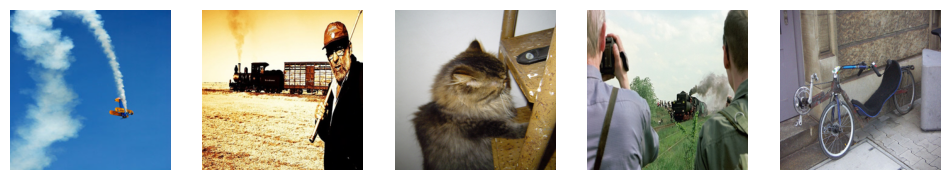

In [34]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6))
axs = axs.flatten()
for i in range(len(output_images)):
    axs[i].imshow(output_images[i])
    axs[i].axis('off')
plt.show()

# Show Ground Truth Mask

In [35]:
def convertMaskToRGB(msk_tensor):
    """
    Given a single-channel mask tensor, converts it into an RGB NumPy array for visualization.

    Args:
        msk_tensor (torch.Tensor): The input mask tensor of shape (B, 1, H, W).

    Returns:
        numpy.ndarray: The mask as an RGB NumPy array of shape (H, W, 3), with colors mapped from the palette.
    """
    # Squeeze batch and channel dimensions to get (H, W) NumPy array
    msk_np = msk_tensor.squeeze(0).squeeze(0).cpu().numpy()

    # Initialize an empty RGB array of shape (H, W, 3)
    height, width = msk_np.shape
    mask_rgb = np.zeros((height, width, 3), dtype=np.uint8)

    # Convert normalized mask values back to class indices (assuming values were k/255.0 originally)
    msk_np = (msk_np * 255).astype(int)

    # Assign RGB colors based on class index
    for class_idx, color in palette.items():
        # Find all pixels belonging to the current class_idx
        indices = msk_np == class_idx
        mask_rgb[indices] = color

    return mask_rgb

In [50]:
def convertPredictedMaskToRGB(msk_tensor):
    """
    Given a single-channel predicted mask tensor (with integer class labels),
    converts it into an RGB NumPy array for visualization.

    Args:
        msk_tensor (torch.Tensor): The input predicted mask tensor of shape (B, 1, H, W),
                                   where pixel values are already integer class indices.

    Returns:
        numpy.ndarray: The mask as an RGB NumPy array of shape (H, W, 3), with colors mapped from the palette.
    """
    # Squeeze batch and channel dimensions to get (H, W) NumPy array
    msk_np = msk_tensor.squeeze(0).squeeze(0).cpu().numpy()

    # Initialize an empty RGB array of shape (H, W, 3)
    height, width = msk_np.shape
    mask_rgb = np.zeros((height, width, 3), dtype=np.uint8)

    # Assign RGB colors based on class index
    for class_idx, color in palette.items():
        # Find all pixels belonging to the current class_idx
        indices = msk_np == class_idx
        mask_rgb[indices] = color

    return mask_rgb

In [52]:
output_msks = [convertMaskToRGB(msk) for msk in msks]

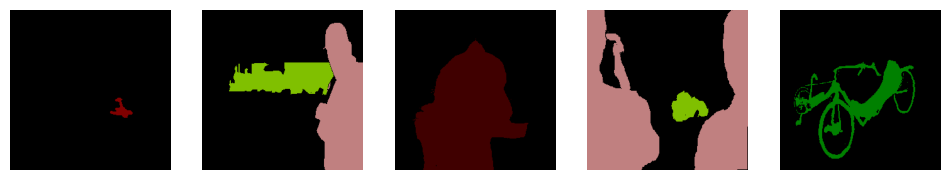

In [53]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6))
axs = axs.flatten()
for i in range(len(output_msks)):
    axs[i].imshow(output_msks[i])
    axs[i].axis('off')
plt.show()

# Plot Image with the mask

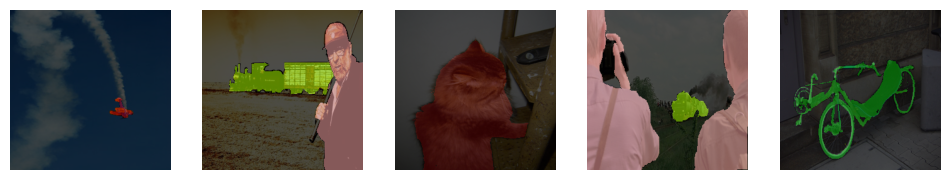

In [54]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6))
axs = axs.flatten()
for i in range(len(output_msks)):
    axs[i].imshow(output_images[i])
    axs[i].imshow(output_msks[i], alpha = 0.7)
    axs[i].axis('off')
plt.show()

# TODO: Visualize Your Model's Predicted Mask

1. Load your model
2. Use the model to predict those images to obtain masks (hint: use your exportModel function)
3. Visualize those masks (without and with images) like we did above

## Visualize Predicted Masks

In [55]:
# Get predicted masks from the model
predicted_logits = [exportModel(new_fcn_model, img) for img in imgs]

# Apply argmax to get the predicted class for each pixel
# The output of FCN is (batch_size, n_class, H, W). Argmax along n_class dimension gives (batch_size, H, W).
predicted_masks_tensor = [torch.argmax(logits, dim=1, keepdim=True) for logits in predicted_logits]

# Convert predicted masks to RGB format for visualization
predicted_msks_rgb = [convertMaskToRGB(msk) for msk in predicted_masks_tensor]

In [56]:
# Convert predicted masks to RGB format for visualization using the new function
predicted_msks_rgb = [convertPredictedMaskToRGB(msk) for msk in predicted_masks_tensor]

### Predicted Masks

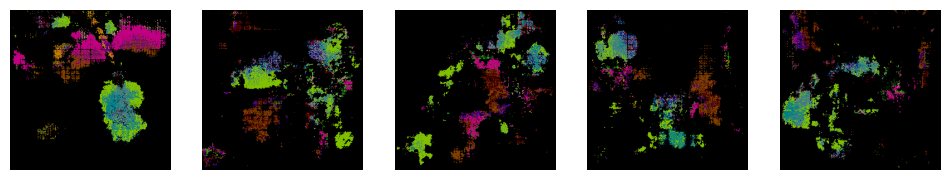

In [59]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6))
axs = axs.flatten()
for i in range(len(predicted_msks_rgb)):
    axs[i].imshow(predicted_msks_rgb[i])
    axs[i].axis('off')
plt.show()

### Predicted Masks Overlaid on Images

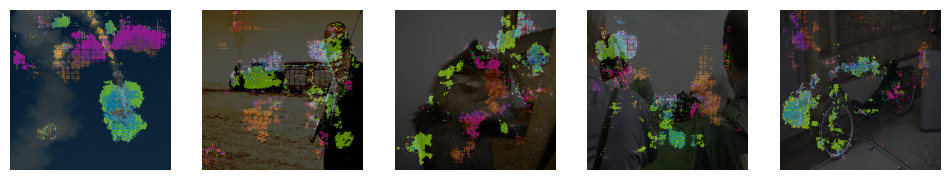

In [60]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6))
axs = axs.flatten()
for i in range(len(predicted_msks_rgb)):
    axs[i].imshow(output_images[i])
    axs[i].imshow(predicted_msks_rgb[i], alpha=0.7)
    axs[i].axis('off')
plt.show()

In [46]:
def exportModel(model, inputs):
    """
    Export the output of the model for given inputs.

    - Set the model to evaluation mode.
    - Perform a forward pass with the model to get output.

    Args:
        model: The PyTorch model, already loaded and in evaluation mode.
        inputs: Input data to the model.

    Returns:
        Output from the model for the given inputs.
    """

    # The model should already be in eval() mode when passed to this function
    # model.eval() # No need to set eval mode here, assume it's already set

    # No need to load state_dict here, assume model is already loaded
    # saved_model_path = "/best_model.pth"
    # model.load_state_dict(torch.load(saved_model_path))

    inputs = inputs.to(device)

    output_image = model(inputs)

    # No need to set train mode here, model's state should be managed externally
    # model.train()  #TURNING THE TRAIN MODE BACK ON TO ENABLE BATCHNORM/DROPOUT!!

    return output_image

In [42]:
new_fcn_model = FCN(n_class=21)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
new_fcn_model.load_state_dict(torch.load('/best_model.pth', map_location=device))
new_fcn_model.to(device)

new_fcn_model.eval()

FCN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bnd1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bnd2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bnd3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bnd4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bnd5): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (deconv1): ConvTranspose2d(512, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (bn1): Ba